# SVM & Naive Bayes

### Support Vector Machines (SVM)

#### 1. What is a Support Vector Machine (SVM)?
A Support Vector Machine (SVM) is a powerful supervised learning algorithm used for classification, regression, and outlier detection. It works by finding the optimal hyperplane that maximizes the margin (the distance) between the data points of different classes.

#### 2. What is the difference between Hard Margin and Soft Margin SVM?
* **Hard Margin SVM:** Only works when the data is perfectly linearly separable. It allows zero misclassifications, which makes it very sensitive to outliers.
* **Soft Margin SVM:** Introduced to handle non-linearly separable data or noisy data. It uses a "slack variable" to allow some points to be misclassified or fall inside the margin to achieve better generalization.

#### 3. What is the mathematical intuition behind SVM?
The intuition is based on maximizing the margin. Mathematically, it aims to find a vector $w$ and a bias $b$ that satisfies $y_i(w \cdot x_i + b) \ge 1$ for all points, while minimizing $||w||^2$. Minimizing $||w||$ is equivalent to maximizing the margin $2/||w||$.

#### 4. What is the role of Lagrange Multipliers in SVM?
Lagrange Multipliers are used to transform the constrained optimization problem of SVM into an unconstrained dual problem. This allows the algorithm to focus only on the support vectors and enables the use of the "Kernel Trick" for non-linear data.

#### 5. What are Support Vectors in SVM?
Support vectors are the data points that lie closest to the decision boundary (hyperplane). They are the "critical" points that define the position and orientation of the hyperplane; removing other data points wouldn't change the boundary, but moving a support vector would.

#### 6. What is a Support Vector Classifier (SVC)?
SVC is the implementation of SVM specifically for classification tasks. It maps data into a high-dimensional space and finds the linear hyperplane that separates classes with the maximum margin.

#### 7. What is a Support Vector Regressor (SVR)?
SVR is the adaptation of SVM for regression. Instead of finding a boundary that separates classes, it tries to find a function that fits as many points as possible within a specified distance ($\epsilon$) from the hyperplane.

#### 8. What is the Kernel Trick in SVM?
The Kernel Trick allows SVM to solve non-linear problems by implicitly mapping the input data into a higher-dimensional feature space without actually calculating the coordinates of the points in that space. It uses a kernel function to compute the inner product between the images of the data points.

#### 9. Compare Linear Kernel, Polynomial Kernel, and RBF Kernel.
* **Linear Kernel:** Used for linearly separable data; fastest to compute.
* **Polynomial Kernel:** Maps data into a polynomial feature space; good for curved boundaries.
* **RBF (Gaussian) Kernel:** The most popular kernel; maps data into an infinite-dimensional space and can handle highly complex, non-linear boundaries.

#### 10. What is the effect of the C parameter in SVM?
The $C$ parameter controls the trade-off between a smooth decision boundary and classifying training points correctly:
* **Small C:** Larger margin, simpler boundary (potential underfitting).
* **Large C:** Smaller margin, tries to classify all training points correctly (potential overfitting).

#### 11. What is the role of the Gamma parameter in RBF Kernel SVM?
Gamma defines how far the influence of a single training example reaches:
* **Low Gamma:** Points far away from the boundary are considered; results in a smoother, broader boundary.
* **High Gamma:** Only points close to the boundary are considered; results in a very complex, "wiggly" boundary that may overfit.

---

### Naive Bayes

#### 12. What is the Naive Bayes classifier, and why is it called "Naive"?
Naive Bayes is a probabilistic classifier based on Bayes' Theorem. it is called "Naive" because it assumes that all features are completely independent of each other, which is rarely true in real-world data.

#### 13. What is Bayes' Theorem?
Bayes' Theorem calculates the probability of an event based on prior knowledge of conditions related to the event.
Formula: $P(A|B) = \frac{P(B|A)P(A)}{P(B)}$

#### 14. Explain the differences between Gaussian, Multinomial, and Bernoulli Naive Bayes.
* **Gaussian NB:** Used when features follow a normal (Gaussian) distribution (e.g., Iris dataset measurements).
* **Multinomial NB:** Used for discrete counts (e.g., word counts in text classification).
* **Bernoulli NB:** Used when features are binary/boolean (e.g., "word present" vs. "word absent").

#### 15. When should you use Gaussian Naive Bayes over other variants?
Use Gaussian NB when your features consist of continuous, real-valued numbers that approximately follow a bell curve distribution.

#### 16. What are the key assumptions made by Naive Bayes?
1.  **Feature Independence:** Every feature is independent of every other feature.
2.  **Equal Importance:** Each feature contributes equally to the final probability.

#### 17. What are the advantages and disadvantages of Naive Bayes?
* **Advantages:** Extremely fast, works well with high-dimensional data (text), and requires little training data.
* **Disadvantages:** The independence assumption is often unrealistic; it can struggle with "zero-frequency" problems (handled by Laplace smoothing).

#### 18. Why is Naive Bayes a good choice for text classification?
It is computationally efficient and handles the high dimensionality of text data (where every unique word is a feature) exceptionally well, even with the independence assumption.

#### 19. Compare SVM and Naive Bayes for classification tasks.
* **SVM:** Better for complex, non-linear boundaries; handles outliers well via Soft Margin; slower to train.
* **Naive Bayes:** Better for very large datasets and text data; extremely fast; assumes feature independence.

#### 20. How does Laplace Smoothing help in Naive Bayes?
Laplace Smoothing (adding a small value like $1$ to the counts) prevents the "zero-probability" problem. If a word appears in the test set but never in the training set, the probability would become zero without smoothing, causing the entire calculation to fail.

### 21. Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy.

In [2]:
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
X, y = load_iris(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = SVC()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9666666666666667


### 22. Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuracies:

In [3]:
from sklearn.svm import SVC
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
X, y = load_wine(return_X_y=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Linear Kernel
linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

# RBF Kernel
rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)
rbf_pred = rbf_model.predict(X_test)

# Results
print("Linear Kernel Accuracy:", accuracy_score(y_test, linear_pred))
print("RBF Kernel Accuracy:", accuracy_score(y_test, rbf_pred))

Linear Kernel Accuracy: 0.9722222222222222
RBF Kernel Accuracy: 0.6111111111111112


### 23. Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean Squared Error (MSE).

In [4]:
from sklearn.svm import SVR
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load dataset
X, y = fetch_california_housing(return_X_y=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train SVR
model = SVR()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 1.3666220544964407


### 24. Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary.

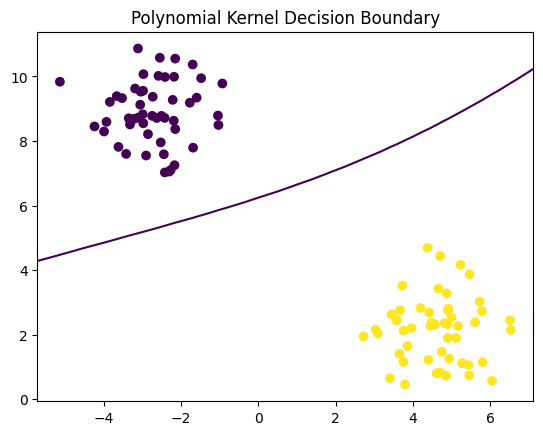

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# Load data (2D for visualization)
X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=42)

# Train model
model = SVC(kernel='poly', degree=3)
model.fit(X, y)

# Plot
plt.scatter(X[:, 0], X[:, 1], c=y)

ax = plt.gca()
xx = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 30)
yy = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 30)
YY, XX = np.meshgrid(yy, xx)

Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()])
Z = Z.reshape(XX.shape)

ax.contour(XX, YY, Z, levels=[0])
plt.title("Polynomial Kernel Decision Boundary")

plt.show()

### 25. Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy.

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
X, y = load_breast_cancer(return_X_y=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = GaussianNB()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9473684210526315


### 26. Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20 Newsgroups dataset.

In [7]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = fetch_20newsgroups(subset='all')

# Convert text to features
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data.data)
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8777188328912466


### 27. Write a Python program to train an SVM Classifier with different C values and compare the decision boundaries visually.

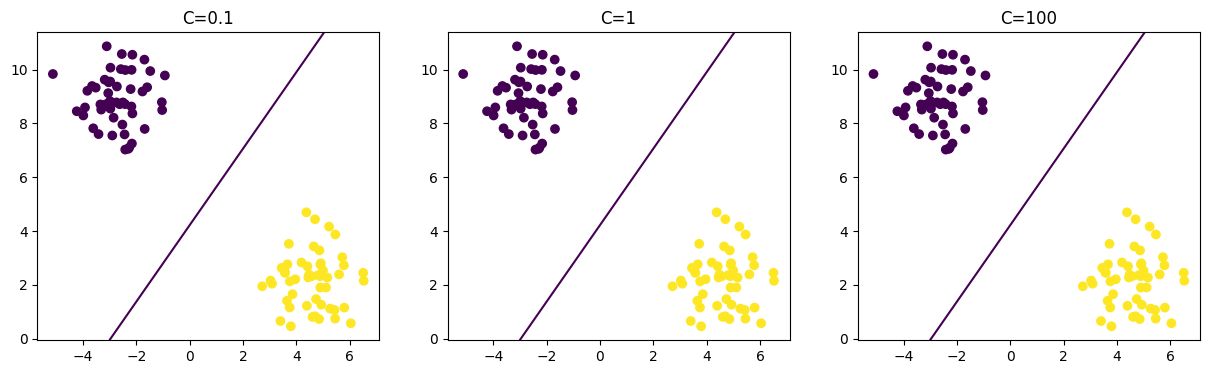

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=42)

C_values = [0.1, 1, 100]

plt.figure(figsize=(15, 4))

for i, C in enumerate(C_values):
    model = SVC(kernel='linear', C=C)
    model.fit(X, y)

    plt.subplot(1, 3, i+1)
    plt.scatter(X[:, 0], X[:, 1], c=y)

    ax = plt.gca()
    xx = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 30)
    yy = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 30)
    YY, XX = np.meshgrid(yy, xx)

    Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()])
    Z = Z.reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[0])
    plt.title(f"C={C}")

plt.show()

### 28. Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with binary features.

In [10]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=1000, n_features=10)
X = (X > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = BernoulliNB()
model.fit(X_train, y_train)

print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.912


### 29. Write a Python program to apply feature scaling before training an SVM model and compare results with unscaled data.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Without scaling
model1 = SVC()
model1.fit(X_train, y_train)
print("Without Scaling:", model1.score(X_test, y_test))

# With scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2 = SVC()
model2.fit(X_train_scaled, y_train)
print("With Scaling:", model2.score(X_test_scaled, y_test))

Without Scaling: 0.7333333333333333
With Scaling: 1.0


### 30. Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and after Laplace Smoothing.

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

model1 = GaussianNB()
model1.fit(X_train, y_train)

model2 = GaussianNB(var_smoothing=1e-2)
model2.fit(X_train, y_train)

print("Default:", model1.score(X_test, y_test))
print("With Smoothing:", model2.score(X_test, y_test))

Default: 0.9370629370629371
With Smoothing: 0.9230769230769231


### 31. Write a Python program to train an SVM Classifier and use GridSearchCV to tune hyperparameters (C, gamma, kernel).

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(SVC(), params, cv=5)
grid.fit(X, y)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


### 32.Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting to improve performance.

In [14]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.metrics import classification_report

X, y = make_classification(n_samples=1000, weights=[0.9, 0.1])

model = SVC(class_weight='balanced')
model.fit(X, y)

print(classification_report(y, model.predict(X)))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97       894
           1       0.67      0.98      0.79       106

    accuracy                           0.95      1000
   macro avg       0.83      0.96      0.88      1000
weighted avg       0.96      0.95      0.95      1000



### 33. Write a Python program to implement a Naïve Bayes classifier for spam detection using email data.

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

texts = ["Win money now", "Hello friend", "Free prize", "Meeting tomorrow"]
labels = [1, 0, 1, 0]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

model = MultinomialNB()
model.fit(X, labels)

print(model.predict(vectorizer.transform(["Free money now"])))

[1]


### 34. Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and compare their accuracy.

In [16]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

svm = SVC()
nb = GaussianNB()

svm.fit(X, y)
nb.fit(X, y)

print("SVM Accuracy:", svm.score(X, y))
print("NB Accuracy:", nb.score(X, y))

SVM Accuracy: 0.9733333333333334
NB Accuracy: 0.96


### 35. Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare results.

In [30]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score

# Load dataset
X, y = load_iris(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# Without Feature Selection
# -------------------------------
model1 = GaussianNB()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)
acc1 = accuracy_score(y_test, y_pred1)

print("Accuracy without feature selection:", acc1)

# -------------------------------
# With Feature Selection
# -------------------------------
selector = SelectKBest(score_func=f_classif, k=2)  # select top 2 features

X_train_new = selector.fit_transform(X_train, y_train)
X_test_new = selector.transform(X_test)

model2 = GaussianNB()
model2.fit(X_train_new, y_train)

y_pred2 = model2.predict(X_test_new)
acc2 = accuracy_score(y_test, y_pred2)

print("Accuracy with feature selection:", acc2)

Accuracy without feature selection: 1.0
Accuracy with feature selection: 1.0


### 36. Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO) strategies and compare accuracy.

In [18]:
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.svm import SVC
from sklearn.datasets import load_wine

X, y = load_wine(return_X_y=True)

ovr = OneVsRestClassifier(SVC())
ovo = OneVsOneClassifier(SVC())

ovr.fit(X, y)
ovo.fit(X, y)

print("OvR:", ovr.score(X, y))
print("OvO:", ovo.score(X, y))

OvR: 0.6853932584269663
OvO: 0.7247191011235955


### 37. Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast Cancer dataset and compare their accuracy.

In [19]:
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

for kernel in ['linear', 'poly', 'rbf']:
    model = SVC(kernel=kernel)
    model.fit(X, y)
    print(kernel, model.score(X, y))

linear 0.9666080843585237
poly 0.9138840070298769
rbf 0.9226713532513181


### 38. Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the average accuracy. 

In [20]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.datasets import load_iris
import numpy as np

X, y = load_iris(return_X_y=True)

kf = StratifiedKFold(n_splits=5)
scores = []

for train, test in kf.split(X, y):
    model = SVC()
    model.fit(X[train], y[train])
    scores.append(model.score(X[test], y[test]))

print("Average Accuracy:", np.mean(scores))

Average Accuracy: 0.9666666666666666


### 39.  Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare performance.

In [31]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load dataset
X, y = load_iris(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Model 1: Default Priors
# -------------------------------
model1 = GaussianNB()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)
acc1 = accuracy_score(y_test, y_pred1)

print("Accuracy with default priors:", acc1)

# -------------------------------
# Model 2: Custom Priors
# -------------------------------
# (must sum to 1 and match number of classes)
model2 = GaussianNB(priors=[0.2, 0.3, 0.5])
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
acc2 = accuracy_score(y_test, y_pred2)

print("Accuracy with custom priors:", acc2)

Accuracy with default priors: 1.0
Accuracy with custom priors: 0.9666666666666667


### 40. Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and compare accuracy.

In [32]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score

# Load dataset
X, y = load_iris(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Without RFE
# -------------------------------
model1 = SVC(kernel='linear')
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)
acc1 = accuracy_score(y_test, y_pred1)

print("Accuracy without RFE:", acc1)

# -------------------------------
# With RFE
# -------------------------------
rfe = RFE(estimator=SVC(kernel='linear'), n_features_to_select=2)

X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

model2 = SVC(kernel='linear')
model2.fit(X_train_rfe, y_train)

y_pred2 = model2.predict(X_test_rfe)
acc2 = accuracy_score(y_test, y_pred2)

print("Accuracy with RFE:", acc2)

Accuracy without RFE: 1.0
Accuracy with RFE: 1.0


### 41. Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy.

In [23]:
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

model = SVC()
model.fit(X, y)

print(classification_report(y, model.predict(X)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.96      0.96      0.96        50
           2       0.96      0.96      0.96        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



### 42. Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss (Cross-Entropy Loss).

In [24]:
from sklearn.metrics import log_loss
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

model = GaussianNB()
model.fit(X, y)

probs = model.predict_proba(X)
print("Log Loss:", log_loss(y, probs))

Log Loss: 0.1112488207471831


### 43. Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn.

<Axes: >

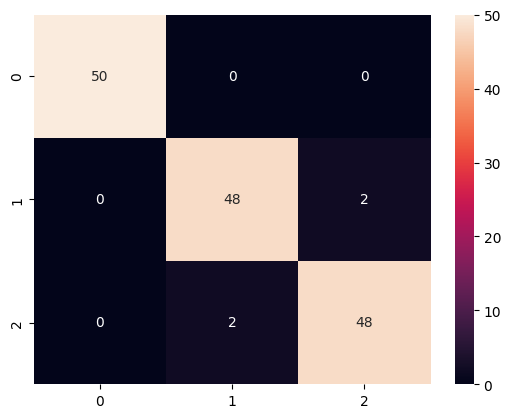

In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

model = SVC()
model.fit(X, y)

cm = confusion_matrix(y, model.predict(X))
sns.heatmap(cm, annot=True)

### 44. Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute Error (MAE) instead of MSE.

In [33]:
from sklearn.svm import SVR
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Load dataset
X, y = fetch_california_housing(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVR model
model = SVR()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate using MAE
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 0.8599506583445771


### 45. Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC score.

In [34]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score

# Load dataset (binary classification)
X, y = load_breast_cancer(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = GaussianNB()
model.fit(X_train, y_train)

# Predict probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# Compute ROC-AUC score
roc_auc = roc_auc_score(y_test, y_probs)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9983622666229938


### 46.  Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.

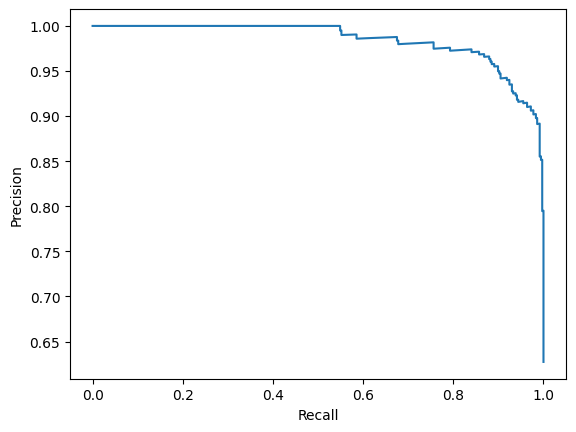

In [28]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

model = SVC(probability=True)
model.fit(X, y)

probs = model.predict_proba(X)[:, 1]
precision, recall, _ = precision_recall_curve(y, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()
